## 1. Import Libraries and Load Dataset

In [6]:
import pandas as pd

df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 2. Data Inspection

In [7]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Rows and Columns: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## 3. Data Cleaning

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
print("Duplicate rows : ",df.duplicated().sum())

Duplicate rows :  0


## 4. Overall Sales and Profit Analysis

In [11]:
print(df[['Order Date','Ship Date']].dtypes)

Order Date    object
Ship Date     object
dtype: object


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [13]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))

Total Sales: 2297200.86
Total Profit: 286397.02


In [14]:
profit_margin = (total_profit / total_sales) * 100

print("Profit Margin:", round(profit_margin, 2), "%")

Profit Margin: 12.47 %


## 5. Sales Trend Over Time

In [15]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

print(yearly_sales)

Order Date
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


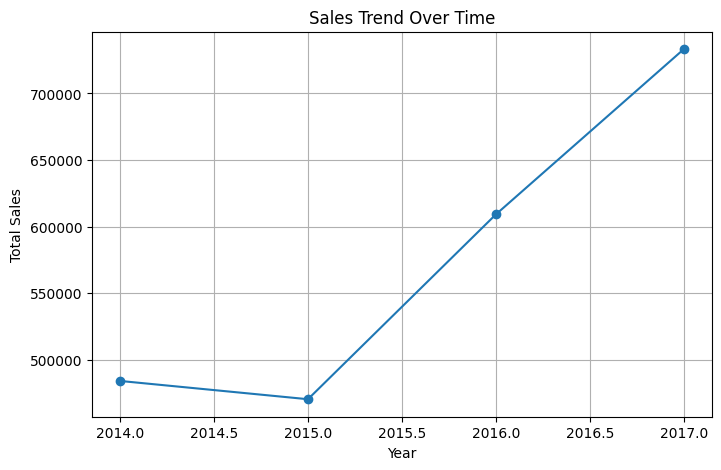

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.title('Sales Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.grid(True)
plt.show()

## 6. Top 10 Products by Sales

In [17]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


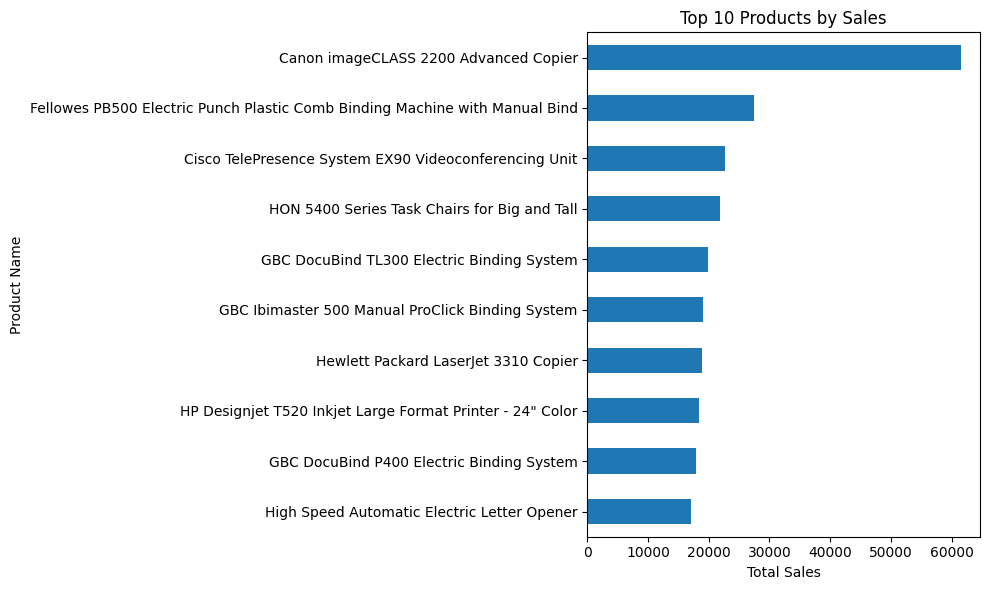

In [18]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

## 7. Sales by Category

In [19]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


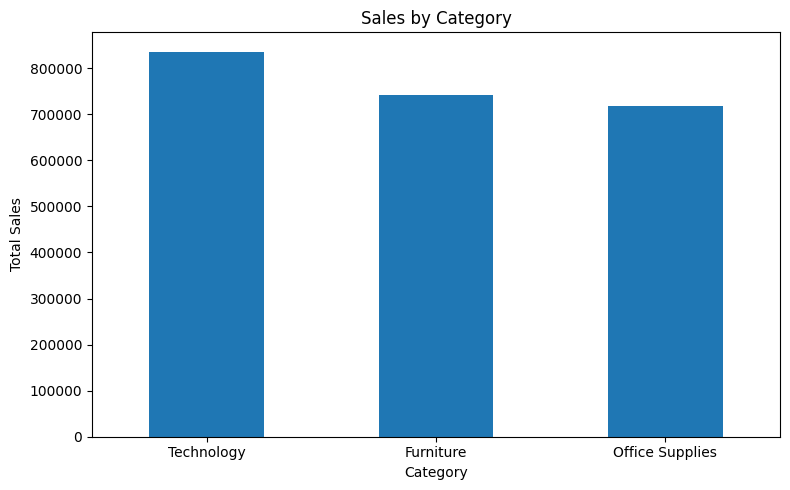

In [20]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Sales by Region

In [21]:
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


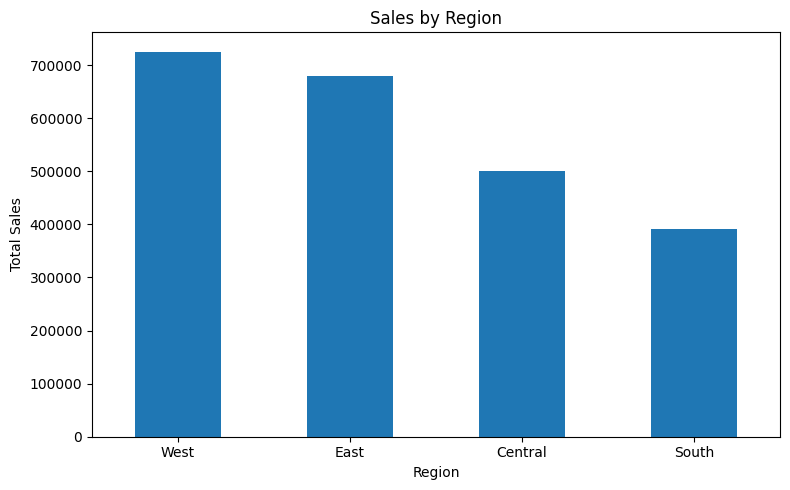

In [22]:
plt.figure(figsize=(8, 5))

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 9. Profit by Category

In [23]:
category_profit = (
    df.groupby('Category')['Profit']
      .sum()
      .sort_values(ascending=False)
)

print(category_profit)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


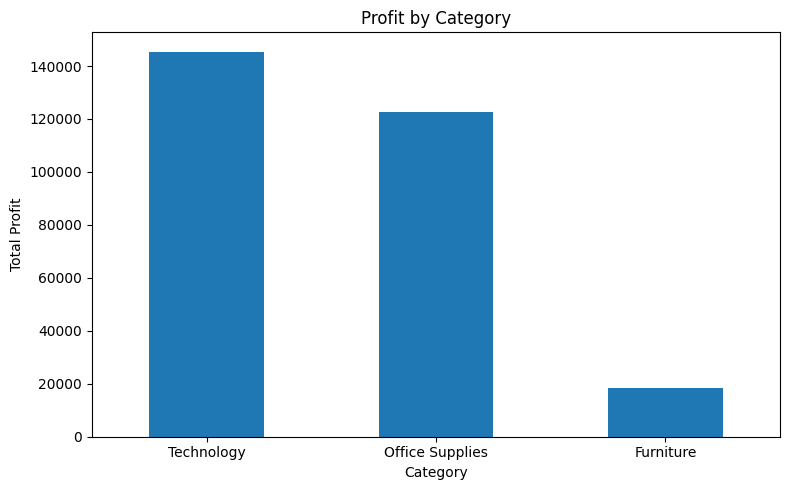

In [24]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [25]:
best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

print("Best-performing region:", best_region)
print("Sales:", round(best_region_sales, 2))

Best-performing region: West
Sales: 725457.82


In [26]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Best-performing category:", best_category)
print("Sales:", round(best_category_sales, 2))

Best-performing category: Technology
Sales: 836154.03


In [27]:
best_profit_category = category_profit.idxmax()
best_category_profit = category_profit.max()

print("Most profitable category:", best_profit_category)
print("Profit:", round(best_category_profit, 2))

Most profitable category: Technology
Profit: 145454.95


In [28]:
least_profit_category = category_profit.idxmin()
least_category_profit = category_profit.min()

print("Least profitable category:", least_profit_category)
print("Profit:", round(least_category_profit, 2))

Least profitable category: Furniture
Profit: 18451.27


In [29]:
highest_product = top_products.index[0]
highest_product_sales = top_products.iloc[0]

lowest_product = top_products.index[-1]
lowest_product_sales = top_products.iloc[-1]

print("Highest-selling product:", highest_product)
print("Sales:", round(highest_product_sales, 2))

print("\nLowest among Top 10 products:", lowest_product)
print("Sales:", round(lowest_product_sales, 2))

Highest-selling product: Canon imageCLASS 2200 Advanced Copier
Sales: 61599.82

Lowest among Top 10 products: High Speed Automatic Electric Letter Opener
Sales: 17030.31


In [30]:
summary = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Profit',
        'Profit Margin',
        'Best Region by Sales',
        'Best Category by Sales',
        'Most Profitable Category',
        'Least Profitable Category',
        'Top-Selling Product'
    ],
    'Value': [
        round(total_sales, 2),
        round(total_profit, 2),
        f'{profit_margin:.2f}%',
        best_region,
        best_category,
        best_profit_category,
        least_profit_category,
        highest_product
    ]
})

summary

,Metric,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Profit Margin,12.47%
3,Best Region by Sales,West
4,Best Category by Sales,Technology
5,Most Profitable Category,Technology
6,Least Profitable Category,Furniture
7,Top-Selling Product,Canon imageCLASS 2200 Advanced Copier


In [31]:
df.to_csv('Superstore_Cleaned.csv', index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [32]:
print("KEY BUSINESS INSIGHTS")
print("-" * 40)

print(f"1. Total sales generated: {total_sales:,.2f}")
print(f"2. Total profit generated: {total_profit:,.2f}")
print(f"3. Overall profit margin: {profit_margin:.2f}%")
print(f"4. Highest-sales region: {best_region}")
print(f"5. Highest-sales category: {best_category}")
print(f"6. Most profitable category: {best_profit_category}")
print(f"7. Least profitable category: {least_profit_category}")
print(f"8. Top-selling product: {highest_product}")

KEY BUSINESS INSIGHTS
----------------------------------------
1. Total sales generated: 2,297,200.86
2. Total profit generated: 286,397.02
3. Overall profit margin: 12.47%
4. Highest-sales region: West
5. Highest-sales category: Technology
6. Most profitable category: Technology
7. Least profitable category: Furniture
8. Top-selling product: Canon imageCLASS 2200 Advanced Copier


# Business Sales Performance Analytics

## Future Interns — Data Science & Analytics Internship

### Objective
The objective of this project is to analyze sales performance and identify
important trends, top-performing products, high-value categories, and
regional performance using the Superstore sales dataset.

### Key Areas of Analysis
- Overall sales and profit performance
- Sales trends over time
- Top 10 products by sales
- Sales performance by category
- Sales performance by region
- Profit performance by category
- Business insights and recommendations

## Key Business Insights

The analysis provides an overview of sales and profitability across
different products, categories, and regions.

- The overall sales and profit figures provide a baseline for evaluating business performance.
- Sales trends help identify changes in business performance over time.
- The top-selling products indicate products contributing significantly to revenue.
- Category-level analysis helps identify areas with stronger sales and profitability.
- Regional analysis highlights differences in sales performance across regions.
- Comparing sales with profit helps identify areas that may require further business attention.

## Business Recommendations

Based on the sales and profitability analysis, the following recommendations
can be considered:

1. **Focus on high-performing products:** Continue promoting products that
   contribute strongly to overall sales and monitor their demand regularly.

2. **Strengthen high-performing categories:** Allocate appropriate marketing
   and sales resources to categories that show strong sales and profitability.

3. **Review lower-profit areas:** Analyze pricing, discounts, product costs,
   and sales strategies for categories with relatively lower profitability.

4. **Use regional performance for planning:** Compare regional sales
   performance to identify opportunities for targeted marketing and business
   expansion.

5. **Monitor sales trends:** Regularly track sales over time to identify
   changes in demand and support better inventory and sales planning.

6. **Balance revenue and profitability:** Business decisions should consider
   both sales revenue and profit rather than focusing on sales alone.

## Conclusion

The analysis of the Superstore sales dataset provides insights into sales
trends, product performance, category performance, regional sales, and
profitability. The findings can help the business identify strong-performing
areas, review lower-profit areas, and make more informed decisions regarding
sales, marketing, and business growth.

# Business Sales Performance Analytics

### Future Interns — Data Science & Analytics Internship

**Task:** Task 1 — Business Sales Performance Analytics  
**Tool:** Python  
**Dataset:** Superstore Sales Dataset  
**Libraries:** Pandas, Matplotlib

---

## Project Overview

This project analyzes sales performance using the Superstore sales dataset.
The analysis focuses on sales trends, top-selling products, category
performance, regional performance, and profitability.

### Business Questions

1. Which products generate the most revenue?
2. How do sales change over time?
3. Which categories and regions perform strongly?
4. Where should the business focus to support growth?

In [33]:
total_orders = df['Order ID'].nunique()

print("Total Orders:", total_orders)

Total Orders: 5009


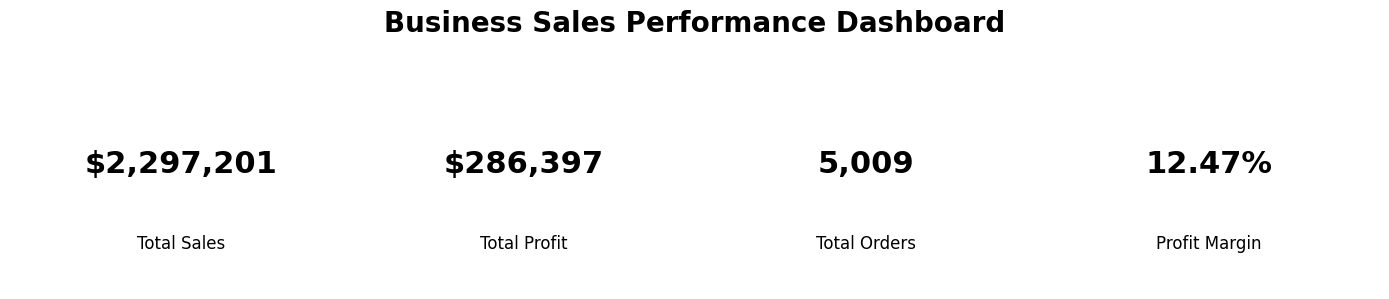

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 3))

ax.axis('off')

# KPI values
kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%")
]

# Create KPI cards
for i, (title, value) in enumerate(kpis):
    ax.text(
        0.125 + i * 0.25,
        0.55,
        value,
        ha='center',
        va='center',
        fontsize=22,
        fontweight='bold'
    )

    ax.text(
        0.125 + i * 0.25,
        0.20,
        title,
        ha='center',
        va='center',
        fontsize=12
    )

plt.suptitle(
    "Business Sales Performance Dashboard",
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

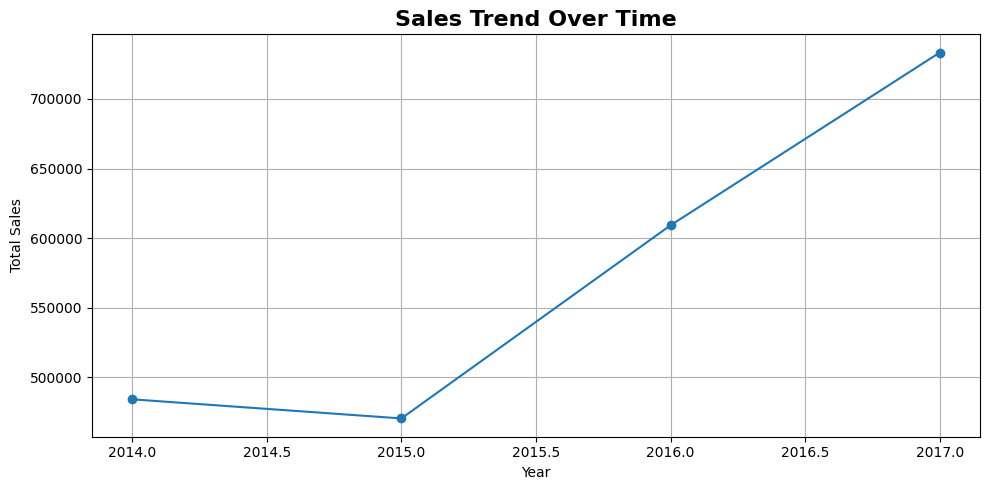

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

plt.title('Sales Trend Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3855/3121068892.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


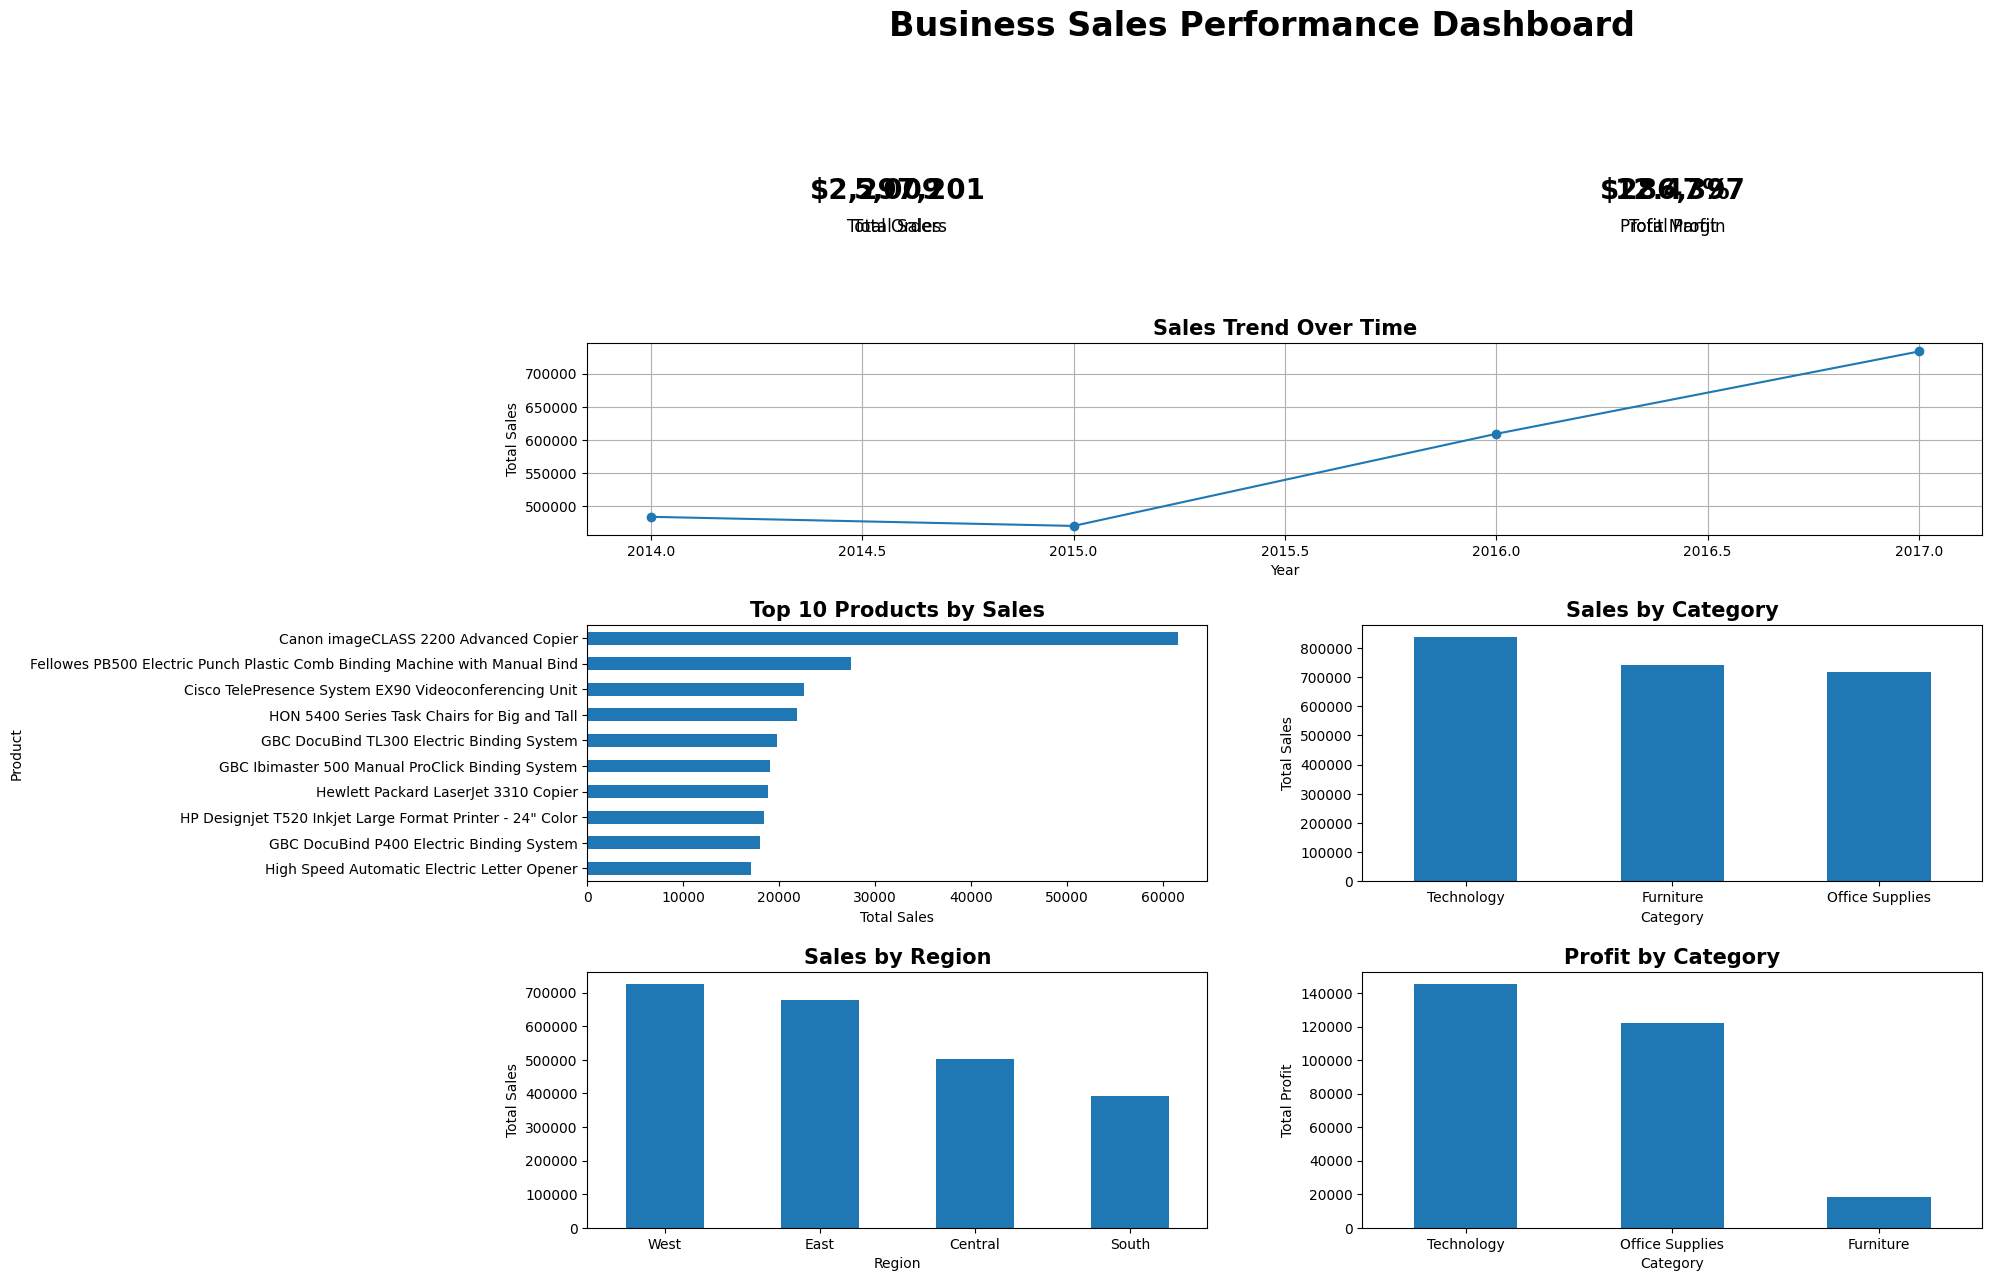

In [36]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 14))

# Create dashboard layout
gs = fig.add_gridspec(
    4, 2,
    height_ratios=[0.8, 1.5, 2, 2],
    hspace=0.45,
    wspace=0.25
)

# -----------------------------
# Dashboard Title
# -----------------------------
fig.suptitle(
    'Business Sales Performance Dashboard',
    fontsize=24,
    fontweight='bold',
    y=0.98
)

# -----------------------------
# KPI Section
# -----------------------------
kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%")
]

for i, (title, value) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i % 2])

    # Hide axes
    ax.axis('off')

    # Display KPI
    ax.text(
        0.5, 0.60,
        value,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
    )

    ax.text(
        0.5, 0.25,
        title,
        ha='center',
        va='center',
        fontsize=12
    )

# -----------------------------
# Sales Trend
# -----------------------------
ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

ax1.set_title(
    'Sales Trend Over Time',
    fontsize=15,
    fontweight='bold'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales')
ax1.grid(True)

# -----------------------------
# Top 10 Products
# -----------------------------
ax2 = fig.add_subplot(gs[2, 0])

top_products.sort_values().plot(
    kind='barh',
    ax=ax2
)

ax2.set_title(
    'Top 10 Products by Sales',
    fontsize=15,
    fontweight='bold'
)

ax2.set_xlabel('Total Sales')
ax2.set_ylabel('Product')

# -----------------------------
# Sales by Category
# -----------------------------
ax3 = fig.add_subplot(gs[2, 1])

category_sales.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title(
    'Sales by Category',
    fontsize=15,
    fontweight='bold'
)

ax3.set_xlabel('Category')
ax3.set_ylabel('Total Sales')
ax3.tick_params(axis='x', rotation=0)

# -----------------------------
# Sales by Region
# -----------------------------
ax4 = fig.add_subplot(gs[3, 0])

region_sales.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Sales by Region',
    fontsize=15,
    fontweight='bold'
)

ax4.set_xlabel('Region')
ax4.set_ylabel('Total Sales')
ax4.tick_params(axis='x', rotation=0)

# -----------------------------
# Profit by Category
# -----------------------------
ax5 = fig.add_subplot(gs[3, 1])

category_profit.plot(
    kind='bar',
    ax=ax5
)

ax5.set_title(
    'Profit by Category',
    fontsize=15,
    fontweight='bold'
)

ax5.set_xlabel('Category')
ax5.set_ylabel('Total Profit')
ax5.tick_params(axis='x', rotation=0)

# Final layout
plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

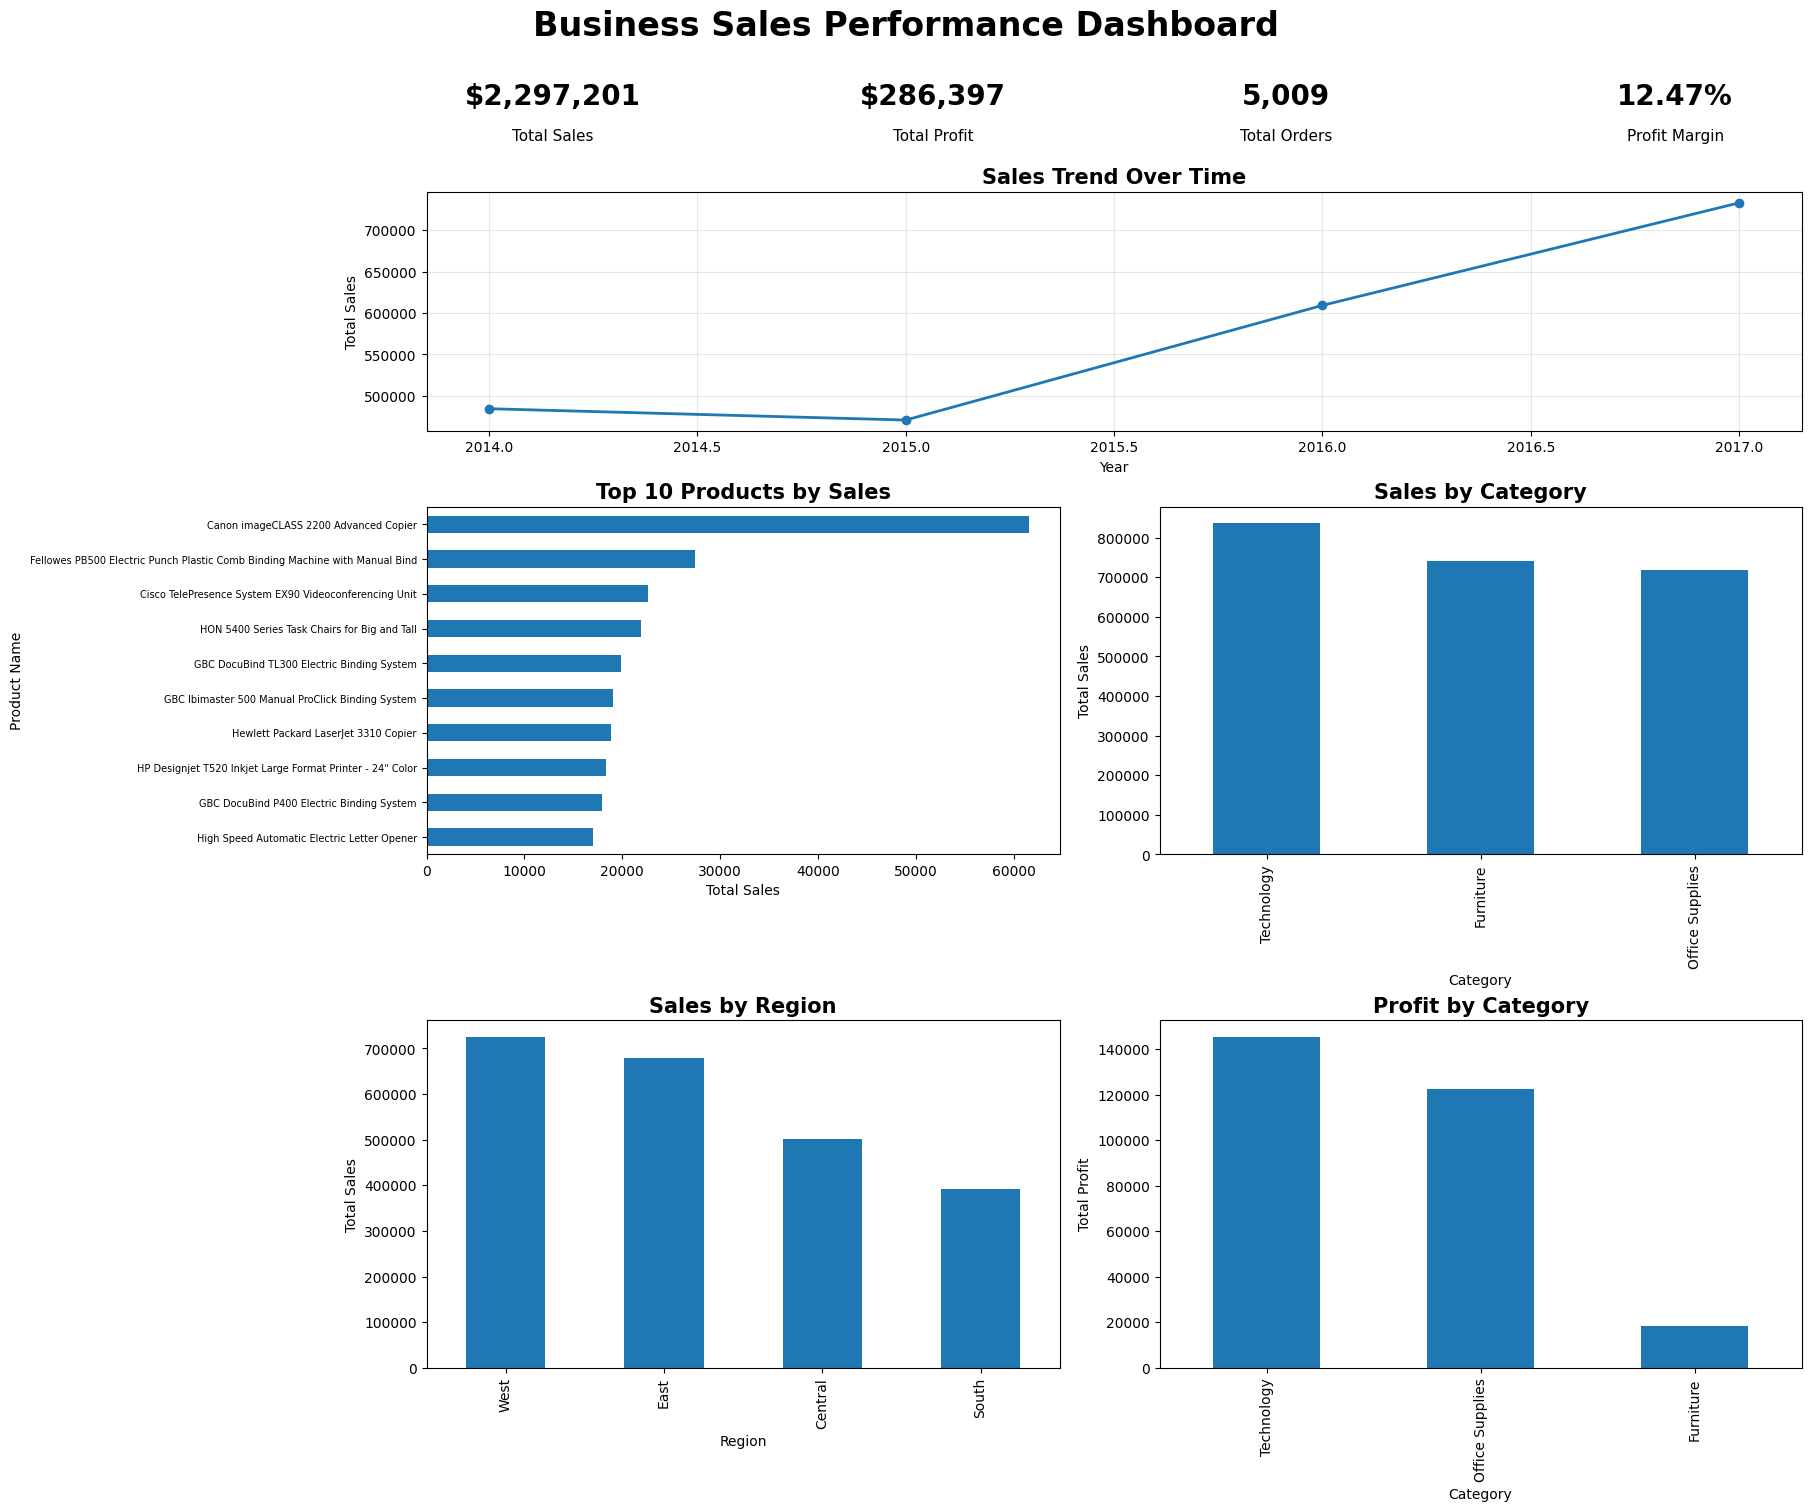

In [37]:
import matplotlib.pyplot as plt

# Create dashboard
fig = plt.figure(figsize=(18, 15), constrained_layout=True)

gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1, 2.2, 3.2, 3.2]
)

# =========================================================
# TITLE
# =========================================================
fig.suptitle(
    'Business Sales Performance Dashboard',
    fontsize=24,
    fontweight='bold'
)

# =========================================================
# KPI CARDS
# =========================================================

kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')

    # KPI value
    ax.text(
        0.5, 0.58,
        value,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
    )

    # KPI title
    ax.text(
        0.5, 0.22,
        title,
        ha='center',
        va='center',
        fontsize=11
    )

# =========================================================
# SALES TREND
# =========================================================

ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o',
    linewidth=2
)

ax1.set_title(
    'Sales Trend Over Time',
    fontsize=15,
    fontweight='bold'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales')
ax1.grid(True, alpha=0.3)

# =========================================================
# TOP 10 PRODUCTS
# =========================================================

ax2 = fig.add_subplot(gs[2, 0:2])

top_products.sort_values().plot(
    kind='barh',
    ax=ax2
)

ax2.set_title(
    'Top 10 Products by Sales',
    fontsize=15,
    fontweight='bold'
)

ax2.set_xlabel('Total Sales')
ax2.set_ylabel('Product Name')

# Make product names smaller
ax2.tick_params(
    axis='y',
    labelsize=7
)

# =========================================================
# SALES BY CATEGORY
# =========================================================

ax3 = fig.add_subplot(gs[2, 2:4])

category_sales.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title(
    'Sales by Category',
    fontsize=15,
    fontweight='bold'
)

ax3.set_xlabel('Category')
ax3.set_ylabel('Total Sales')

# =========================================================
# SALES BY REGION
# =========================================================

ax4 = fig.add_subplot(gs[3, 0:2])

region_sales.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Sales by Region',
    fontsize=15,
    fontweight='bold'
)

ax4.set_xlabel('Region')
ax4.set_ylabel('Total Sales')

# =========================================================
# PROFIT BY CATEGORY
# =========================================================

ax5 = fig.add_subplot(gs[3, 2:4])

category_profit.plot(
    kind='bar',
    ax=ax5
)

ax5.set_title(
    'Profit by Category',
    fontsize=15,
    fontweight='bold'
)

ax5.set_xlabel('Category')
ax5.set_ylabel('Total Profit')

# =========================================================
# DISPLAY
# =========================================================

plt.show()

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


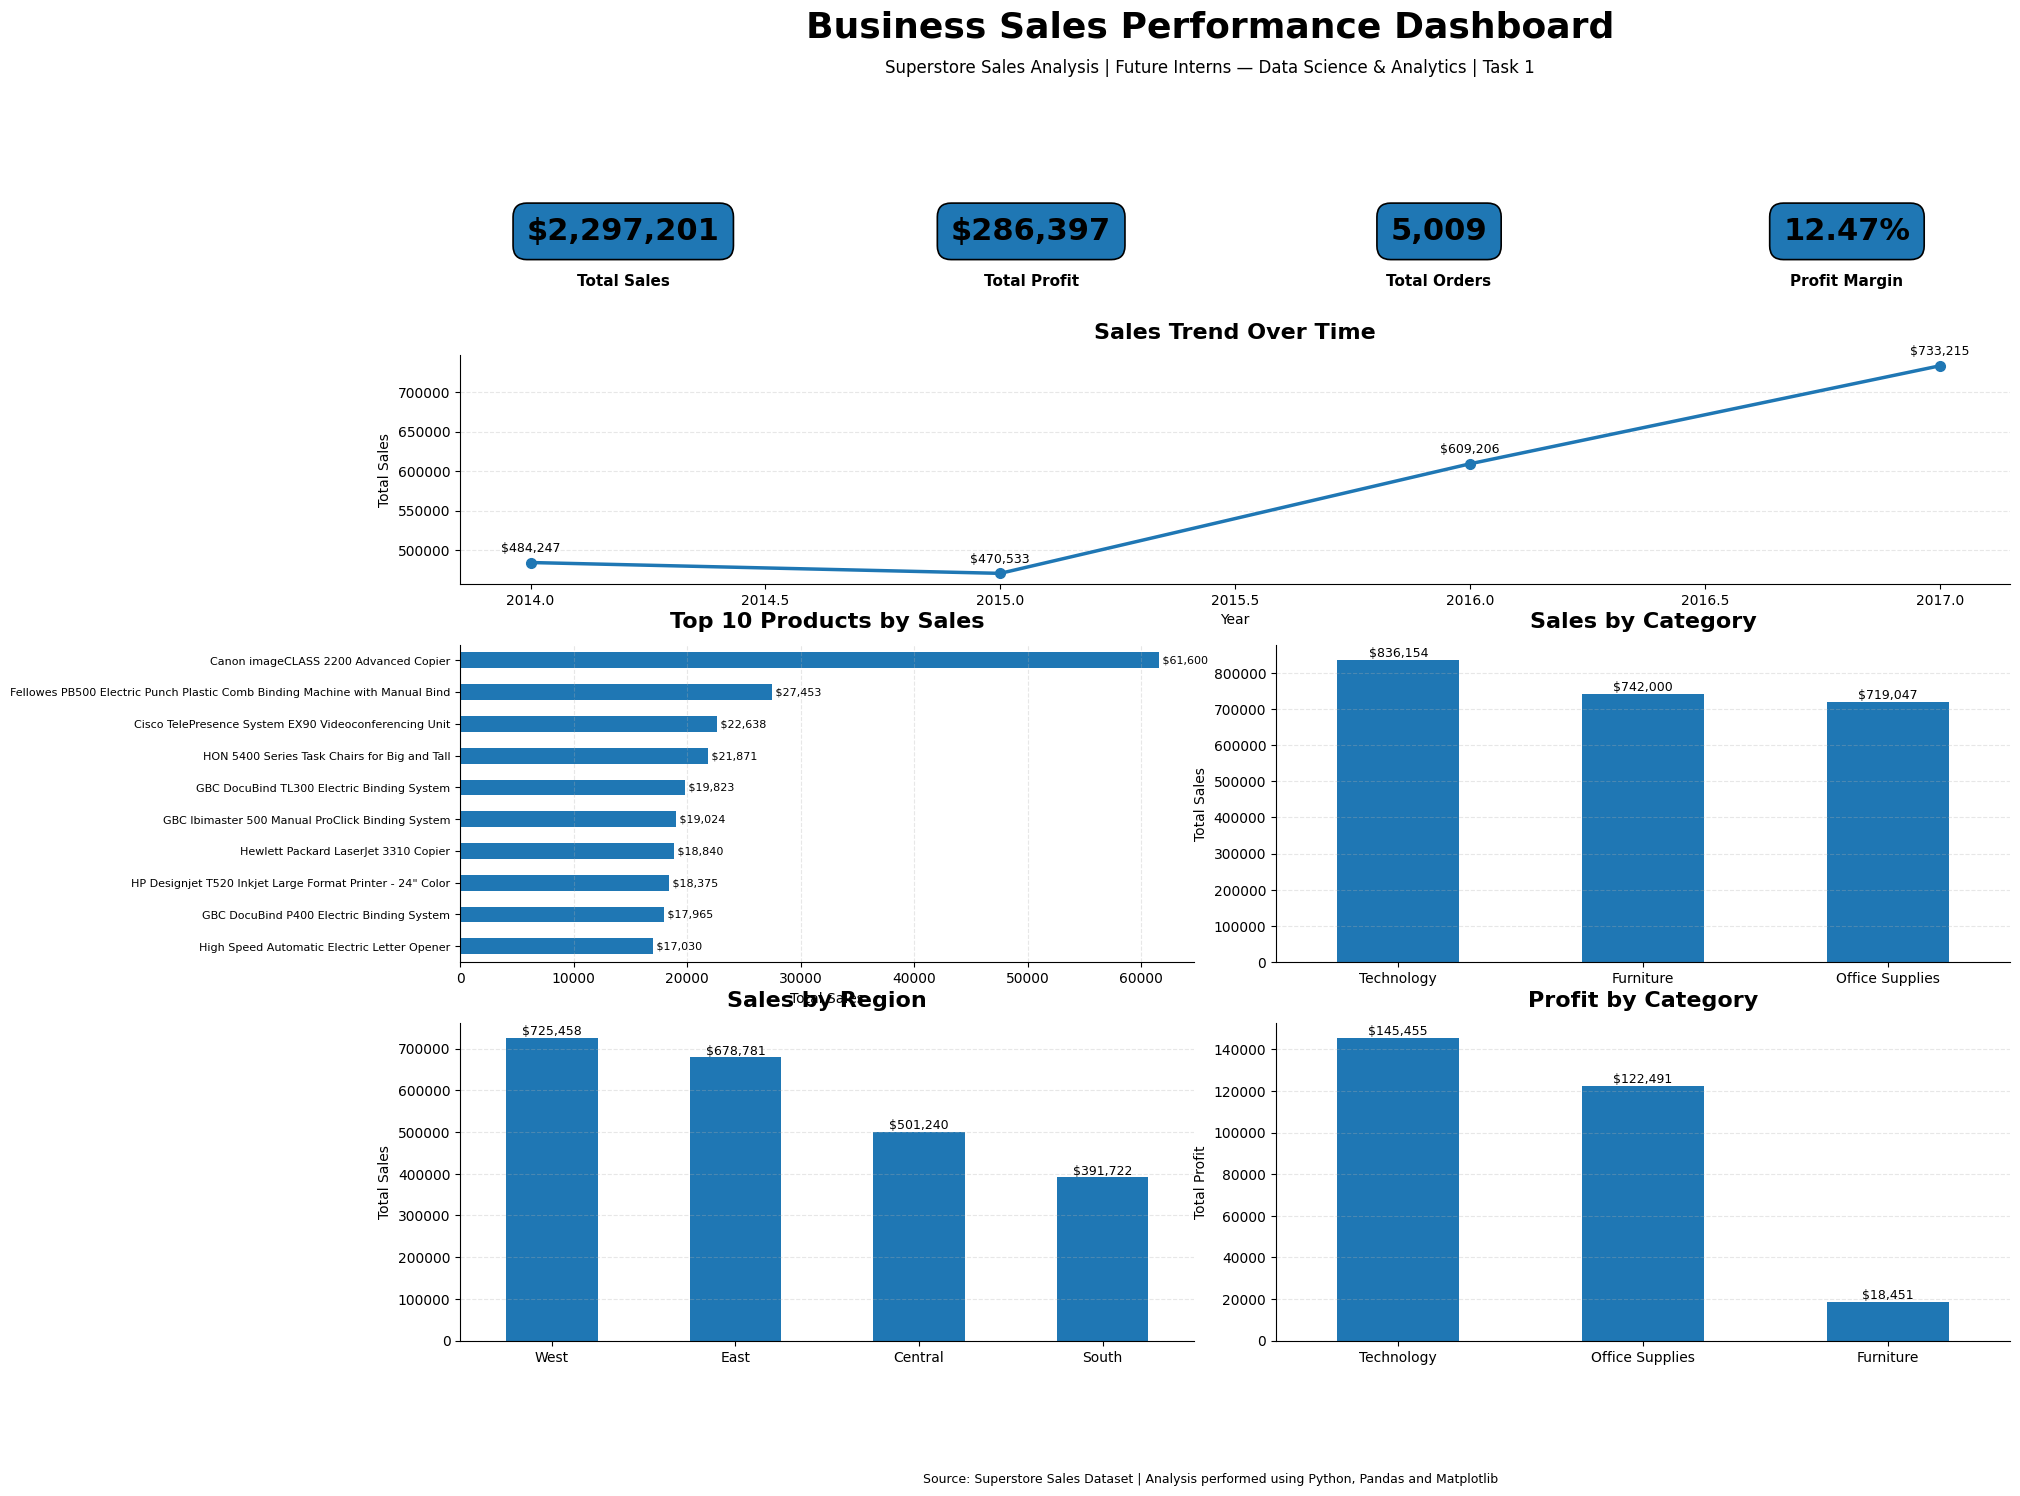

In [38]:
import matplotlib.pyplot as plt

# =========================================================
# PROFESSIONAL BUSINESS SALES PERFORMANCE DASHBOARD
# =========================================================

fig = plt.figure(figsize=(20, 15), constrained_layout=True)

gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1.1, 2.3, 3.2, 3.2],
    hspace=0.25,
    wspace=0.25
)

# =========================================================
# MAIN TITLE
# =========================================================

fig.suptitle(
    'Business Sales Performance Dashboard',
    fontsize=26,
    fontweight='bold'
)

fig.text(
    0.5, 0.955,
    'Superstore Sales Analysis | Future Interns — Data Science & Analytics | Task 1',
    ha='center',
    fontsize=12
)

# =========================================================
# KPI CARDS
# =========================================================

kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')

    # KPI card
    ax.text(
        0.5, 0.58,
        value,
        ha='center',
        va='center',
        fontsize=22,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.45',
            linewidth=1.2
        )
    )

    ax.text(
        0.5, 0.12,
        title,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# =========================================================
# SALES TREND
# =========================================================

ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o',
    linewidth=2.5,
    markersize=7
)

# Add values above points
for x, y in zip(yearly_sales.index, yearly_sales.values):
    ax1.annotate(
        f'${y:,.0f}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center',
        fontsize=9
    )

ax1.set_title(
    'Sales Trend Over Time',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Total Sales', fontsize=10)

ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# =========================================================
# TOP 10 PRODUCTS
# =========================================================

ax2 = fig.add_subplot(gs[2, 0:2])

top_products_sorted = top_products.sort_values()

top_products_sorted.plot(
    kind='barh',
    ax=ax2
)

ax2.set_title(
    'Top 10 Products by Sales',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax2.set_xlabel('Total Sales', fontsize=10)
ax2.set_ylabel('')

ax2.tick_params(
    axis='y',
    labelsize=8
)

ax2.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Add values to bars
for i, value in enumerate(top_products_sorted.values):
    ax2.text(
        value,
        i,
        f' ${value:,.0f}',
        va='center',
        fontsize=8
    )

# =========================================================
# SALES BY CATEGORY
# =========================================================

ax3 = fig.add_subplot(gs[2, 2:4])

category_sales.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title(
    'Sales by Category',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax3.set_xlabel('')
ax3.set_ylabel('Total Sales', fontsize=10)

ax3.tick_params(
    axis='x',
    rotation=0
)

ax3.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Add values
for i, value in enumerate(category_sales.values):
    ax3.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# =========================================================
# SALES BY REGION
# =========================================================

ax4 = fig.add_subplot(gs[3, 0:2])

region_sales.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Sales by Region',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax4.set_xlabel('')
ax4.set_ylabel('Total Sales', fontsize=10)

ax4.tick_params(
    axis='x',
    rotation=0
)

ax4.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# Add values
for i, value in enumerate(region_sales.values):
    ax4.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# =========================================================
# PROFIT BY CATEGORY
# =========================================================

ax5 = fig.add_subplot(gs[3, 2:4])

category_profit.plot(
    kind='bar',
    ax=ax5
)

ax5.set_title(
    'Profit by Category',
    fontsize=16,
    fontweight='bold',
    pad=12
)

ax5.set_xlabel('')
ax5.set_ylabel('Total Profit', fontsize=10)

ax5.tick_params(
    axis='x',
    rotation=0
)

ax5.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# Add values
for i, value in enumerate(category_profit.values):
    ax5.text(
        i,
        value,
        f'${value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# =========================================================
# FOOTER
# =========================================================

fig.text(
    0.5, 0.015,
    'Source: Superstore Sales Dataset | Analysis performed using Python, Pandas and Matplotlib',
    ha='center',
    fontsize=9
)

# =========================================================
# DISPLAY
# =========================================================

plt.show()

/tmp/ipykernel_3855/217067839.py:230: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


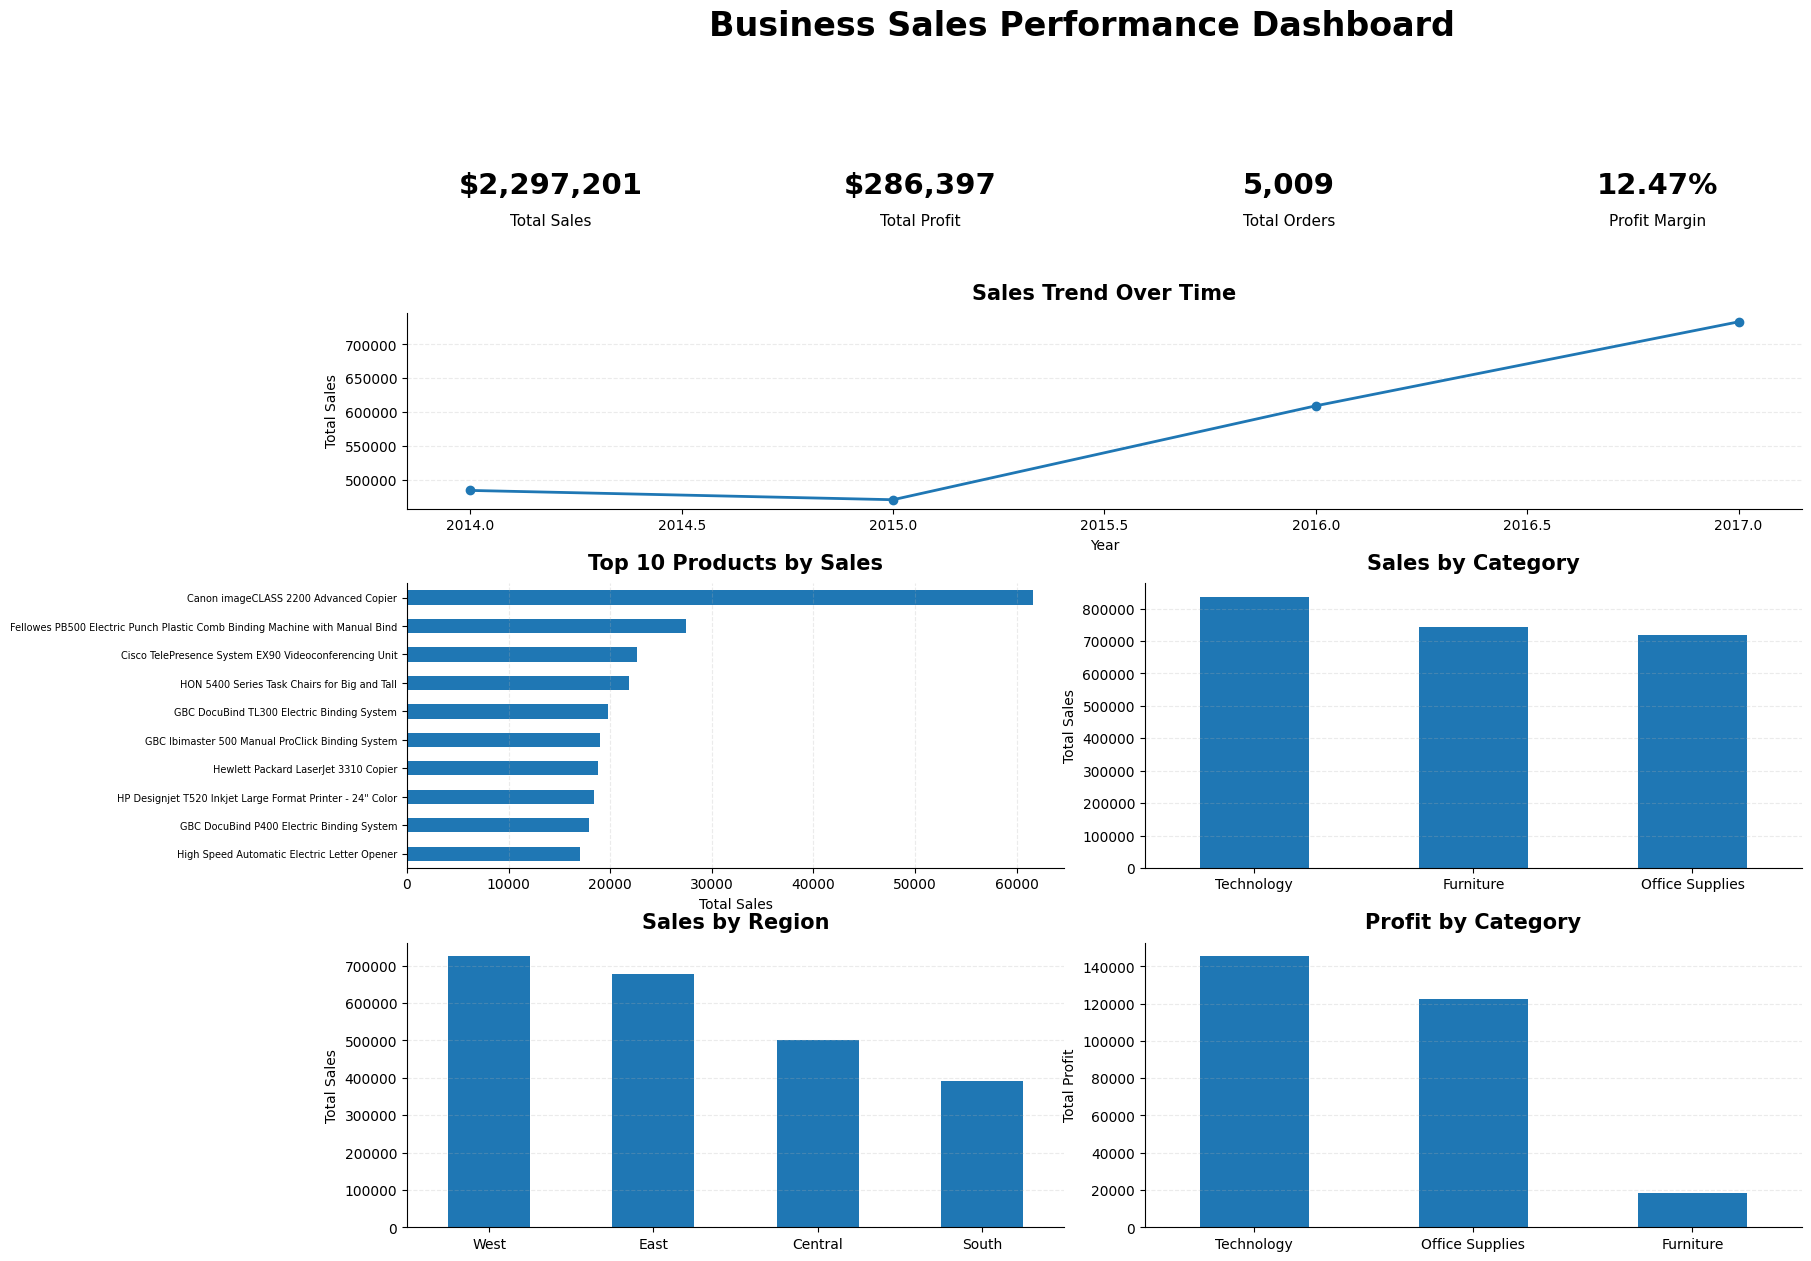

In [44]:
import matplotlib.pyplot as plt

# =========================================================
# FINAL BUSINESS SALES PERFORMANCE DASHBOARD
# =========================================================

fig = plt.figure(figsize=(18, 14))

gs = fig.add_gridspec(
    4, 4,
    height_ratios=[1, 2.2, 3.2, 3.2],
    hspace=0.35,
    wspace=0.28
)

# =========================================================
# TITLE
# =========================================================

fig.suptitle(
    'Business Sales Performance Dashboard',
    fontsize=24,
    fontweight='bold',
    y=0.98
)

# =========================================================
# KPI SECTION
# =========================================================

kpis = [
    ("Total Sales", f"${total_sales:,.0f}"),
    ("Total Profit", f"${total_profit:,.0f}"),
    ("Total Orders", f"{total_orders:,}"),
    ("Profit Margin", f"{profit_margin:.2f}%")
]

for i, (title, value) in enumerate(kpis):

    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')

    ax.text(
        0.5, 0.60,
        value,
        ha='center',
        va='center',
        fontsize=21,
        fontweight='bold'
    )

    ax.text(
        0.5, 0.20,
        title,
        ha='center',
        va='center',
        fontsize=11
    )

# =========================================================
# SALES TREND
# =========================================================

ax1 = fig.add_subplot(gs[1, :])

ax1.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o',
    linewidth=2
)

ax1.set_title(
    'Sales Trend Over Time',
    fontsize=15,
    fontweight='bold',
    pad=10
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Sales')

# Keep only light horizontal gridlines
ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

# Remove unnecessary borders
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# =========================================================
# TOP 10 PRODUCTS
# =========================================================

ax2 = fig.add_subplot(gs[2, 0:2])

top_products.sort_values().plot(
    kind='barh',
    ax=ax2
)

ax2.set_title(
    'Top 10 Products by Sales',
    fontsize=15,
    fontweight='bold',
    pad=10
)

ax2.set_xlabel('Total Sales')
ax2.set_ylabel('')

# Smaller product names so they don't overlap
ax2.tick_params(
    axis='y',
    labelsize=7
)

ax2.grid(
    axis='x',
    linestyle='--',
    alpha=0.25
)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# =========================================================
# SALES BY CATEGORY
# =========================================================

ax3 = fig.add_subplot(gs[2, 2:4])

category_sales.plot(
    kind='bar',
    ax=ax3
)

ax3.set_title(
    'Sales by Category',
    fontsize=15,
    fontweight='bold',
    pad=10
)

ax3.set_xlabel('')
ax3.set_ylabel('Total Sales')

ax3.tick_params(axis='x', rotation=0)

ax3.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# =========================================================
# SALES BY REGION
# =========================================================

ax4 = fig.add_subplot(gs[3, 0:2])

region_sales.plot(
    kind='bar',
    ax=ax4
)

ax4.set_title(
    'Sales by Region',
    fontsize=15,
    fontweight='bold',
    pad=10
)

ax4.set_xlabel('')
ax4.set_ylabel('Total Sales')

ax4.tick_params(axis='x', rotation=0)

ax4.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# =========================================================
# PROFIT BY CATEGORY
# =========================================================

ax5 = fig.add_subplot(gs[3, 2:4])

category_profit.plot(
    kind='bar',
    ax=ax5
)

ax5.set_title(
    'Profit by Category',
    fontsize=15,
    fontweight='bold',
    pad=10
)

ax5.set_xlabel('')
ax5.set_ylabel('Total Profit')

ax5.tick_params(axis='x', rotation=0)

ax5.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save the dashboard BEFORE displaying it
fig.savefig(
    'Business_Sales_Performance_Dashboard.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

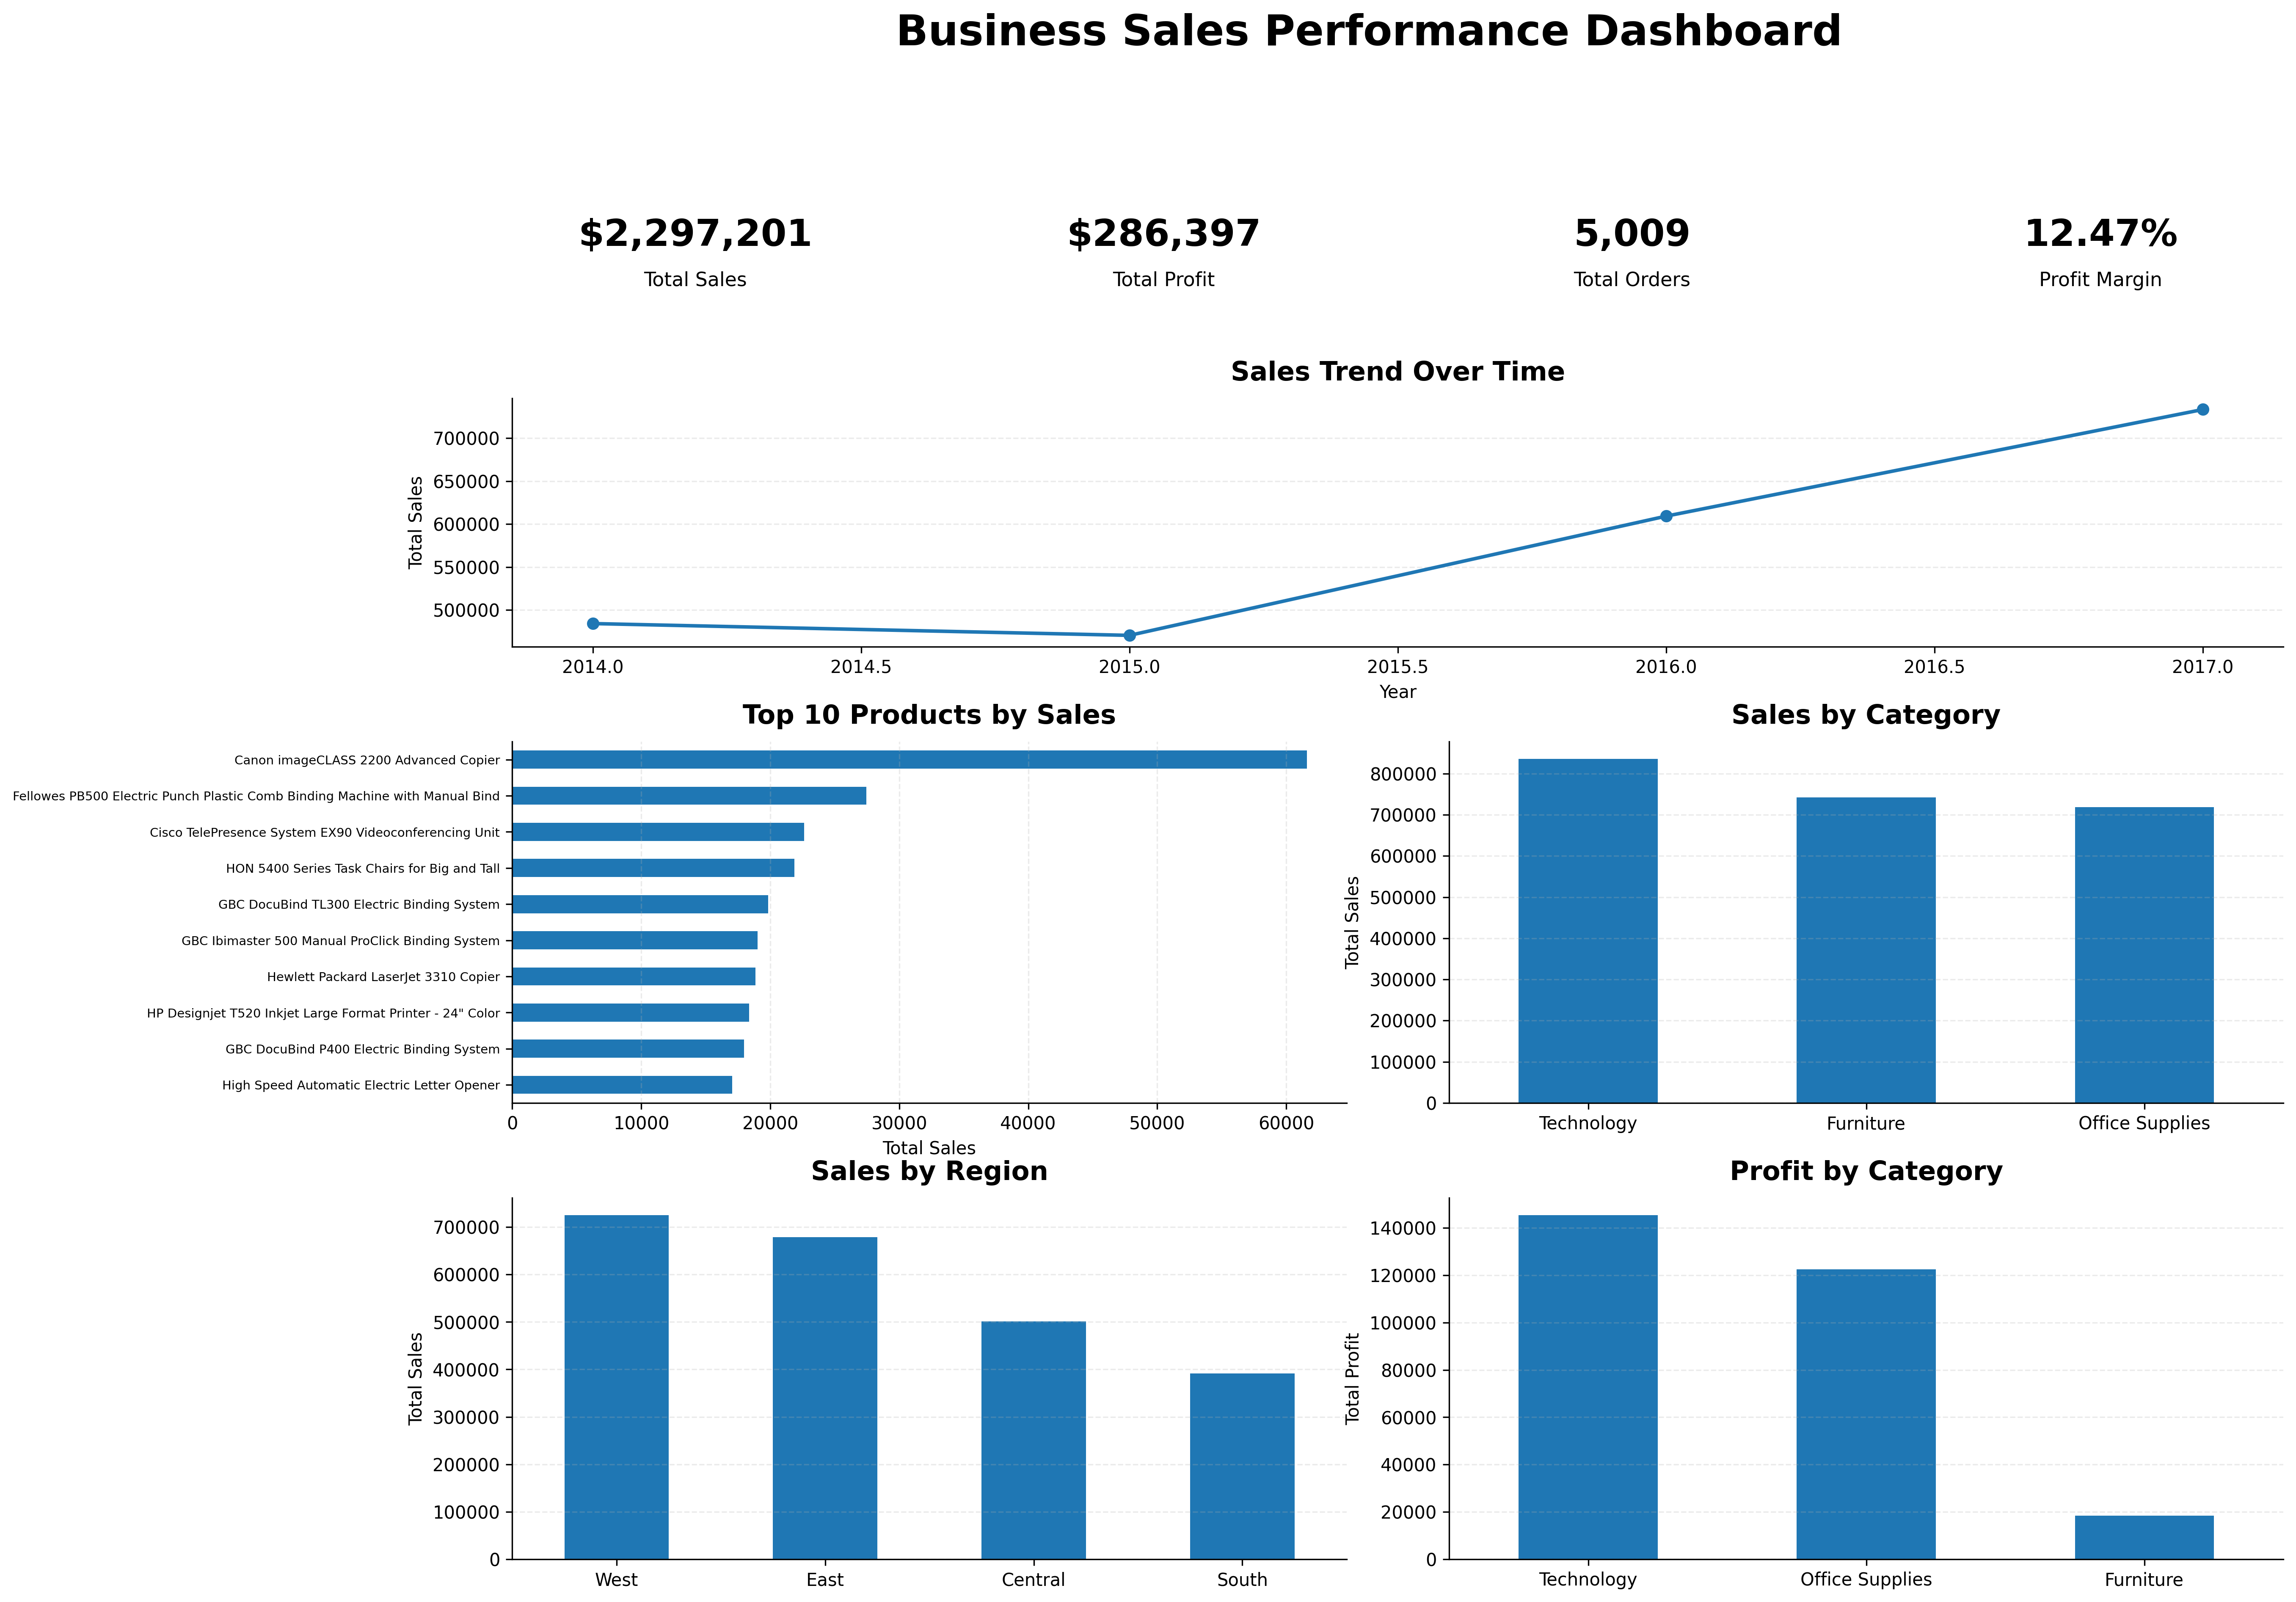

In [46]:
from PIL import Image
from IPython.display import display

display(Image.open('Business_Sales_Performance_Dashboard.png'))

In [40]:
plt.savefig(
    'Business_Sales_Performance_Dashboard.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
import os

print(os.path.exists('Business_Sales_Performance_Dashboard.png'))

True


In [42]:
from PIL import Image
import os

file_path = 'Business_Sales_Performance_Dashboard.png'

print("File exists:", os.path.exists(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

img = Image.open(file_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

File exists: True
File size: 15128 bytes
Image size: (1980, 1499)
Image mode: RGBA


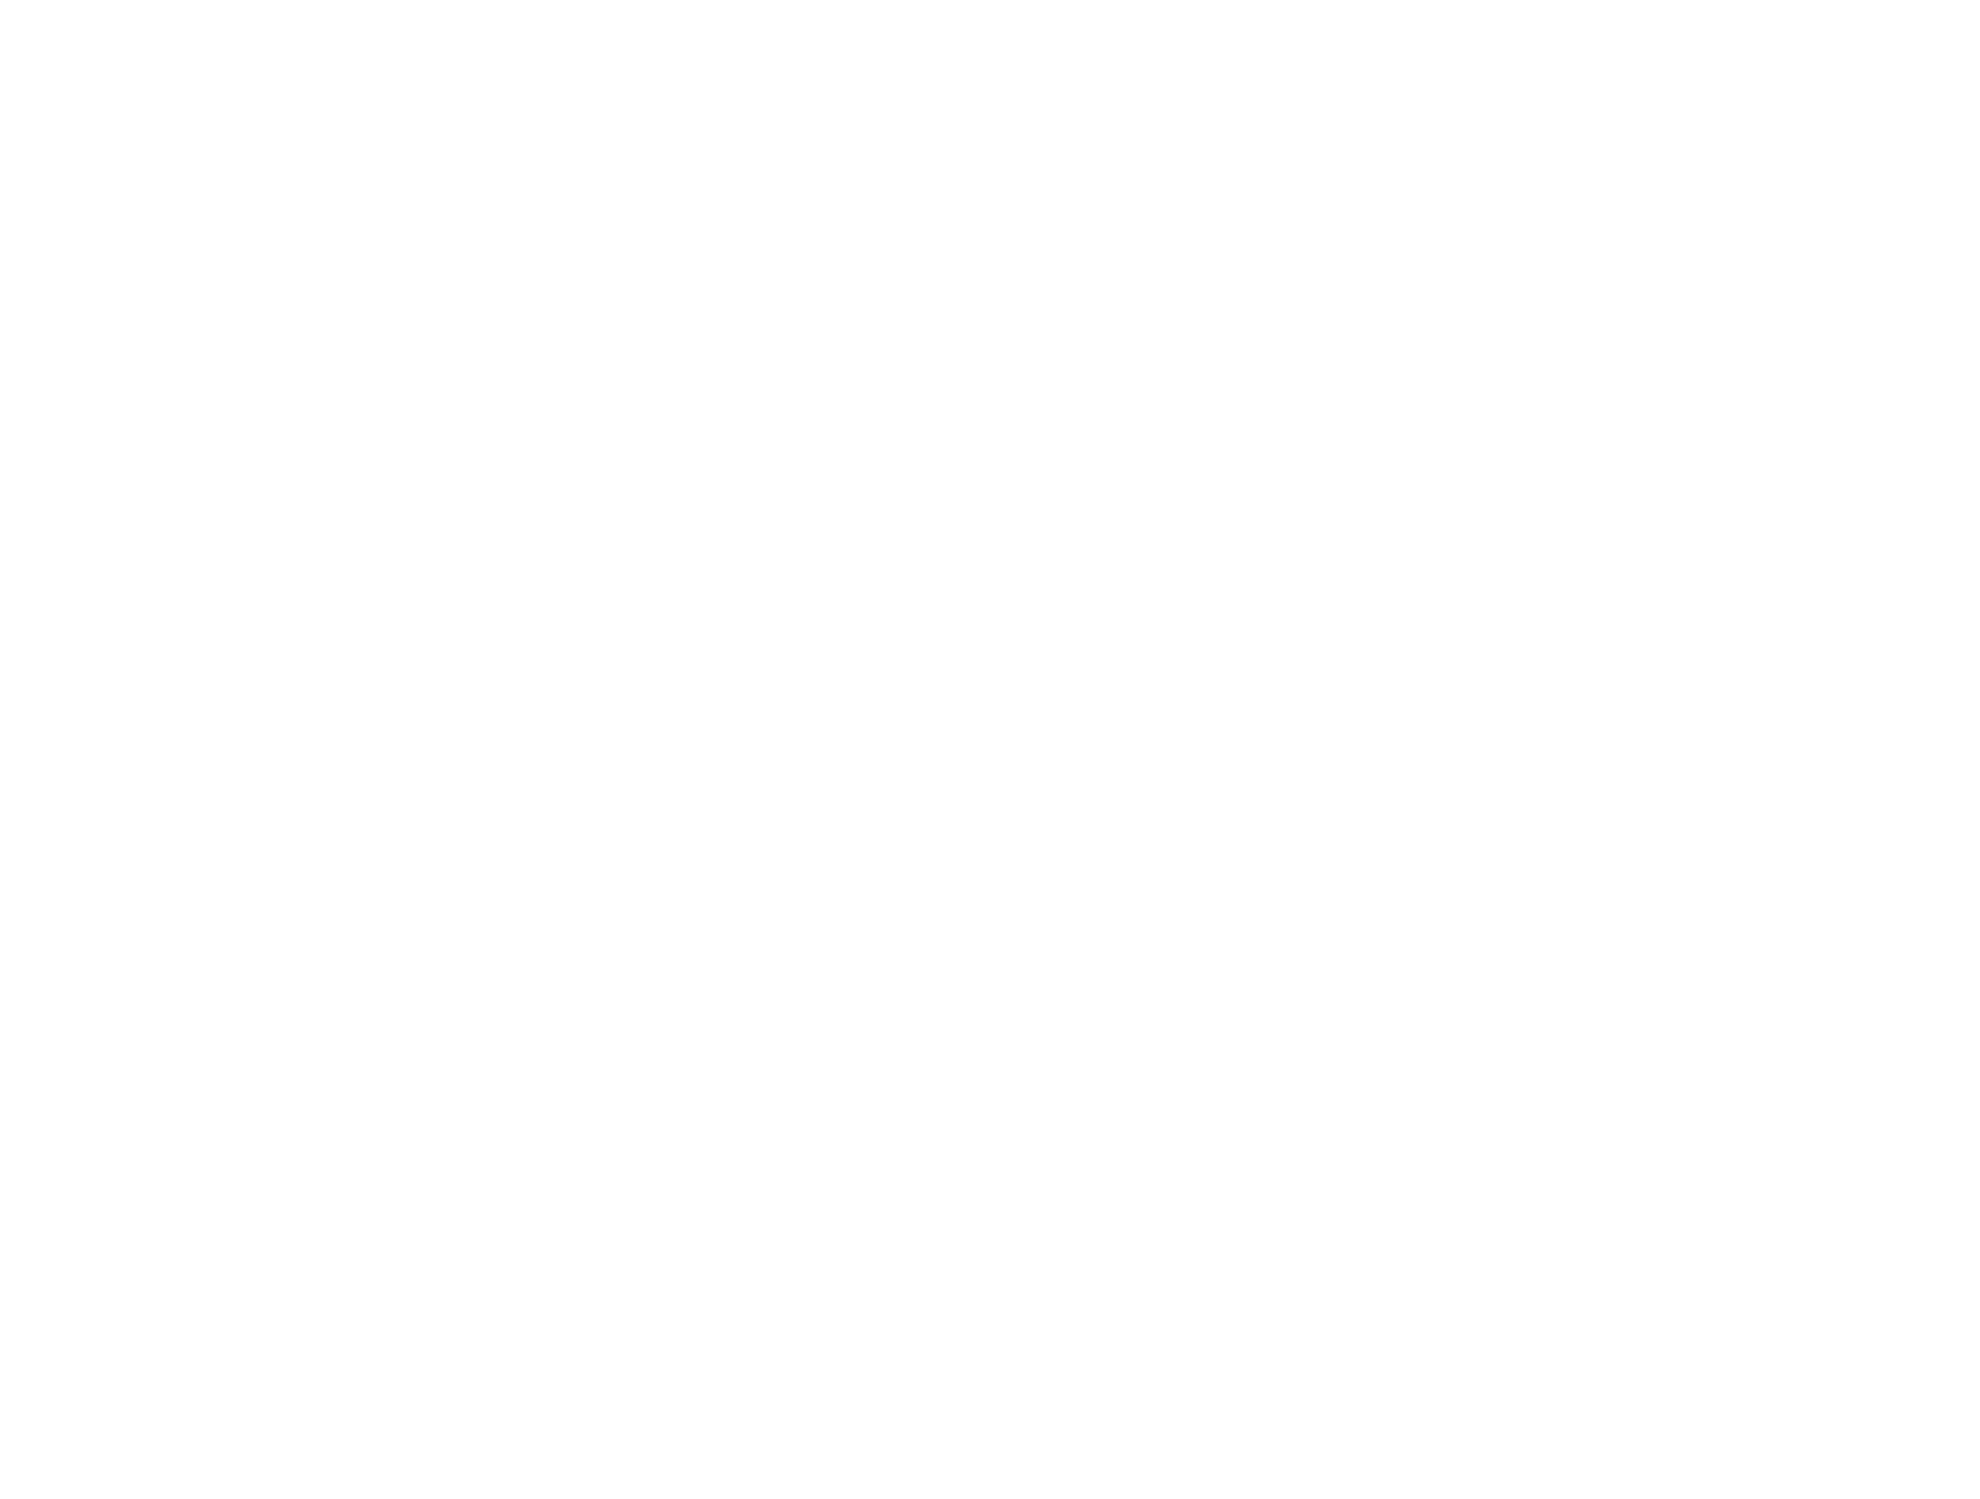

In [43]:
from IPython.display import display

display(Image.open('Business_Sales_Performance_Dashboard.png'))